# imports

In [1]:
import os
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm import tqdm
import seaborn as sns
from pathlib import Path
import astropy.units as u
from spectres import spectres

In [2]:
import lifesim
import os, sys
os.chdir("/home/kirschkobold/documents/life_internship/LIFEsim_yields")
sys.path.insert(0, os.getcwd())

# reference lifesim setup

In [3]:
integration_time = 55*60*60

In [4]:
bus = lifesim.Bus()

instrument = lifesim.Instrument(name='inst')
bus.add_module(instrument)

transm = lifesim.TransmissionMap(name='transm')
bus.add_module(transm)

exo = lifesim.PhotonNoiseExozodi(name='exo')
bus.add_module(exo)
local = lifesim.PhotonNoiseLocalzodi(name='local')
bus.add_module(local)
star = lifesim.PhotonNoiseStar(name='star')
bus.add_module(star)
# mirror = lifesim.PhotonNoiseThermal(name='mirror')
# bus.add_module(mirror)
# darkcurrent = lifesim.ElectronNoiseDarkCurrent(name='darkcurrent')
# bus.add_module(darkcurrent)


# connect all modules
bus.connect(('inst', 'transm'))
bus.connect(('inst', 'exo'))
bus.connect(('inst', 'local'))
bus.connect(('inst', 'star'))
# bus.connect(('inst', 'mirror'))
# bus.connect(('inst', 'darkcurrent'))


bus.connect(('star', 'transm'))

In [5]:
bus.data.options.set_scenario('baseline')
bus.data.options.set_manual(spec_res=100,
                            image_size=256)

instrument.apply_options()

In [6]:
data=pd.read_csv('/home/kirschkobold/documents/life_internship/LIFEsim_yields/kira_testing/Earth_PRTunits_10pc.txt',header=None, sep='\s+')

lam_PRT=data[0].values*u.micron
f_PRT=data[1].values*u.erg/u.cm**2/u.s/u.Hz
f_lifesim = f_PRT.to(u.photon / u.m**2 / u.s / u.micron,\
                      equivalencies=u.spectral_density(lam_PRT))

#f_lifesim = f_lifesim.to(u.photon / u.s / u.meter**3)
lam_lifesim = lam_PRT.to(u.micron)
f_lifesim *= np.diff(lam_lifesim.value, append=[0]) * u.micron
lam_lifesim = lam_lifesim.to(u.meter)

f_lifesim = f_lifesim[:-1]
lam_lifesim = lam_lifesim[:-1]

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_85501/760150314.py:1: SyntaxWarning: invalid escape sequence '\s'
  data=pd.read_csv('/home/kirschkobold/documents/life_internship/LIFEsim_yields/kira_testing/Earth_PRTunits_10pc.txt',header=None, sep='\s+')


# catalog comparison

## catalog and ref

In [14]:
bus.data.catalog_from_ppop(input_path='/home/kirschkobold/documents/life_internship/LIFEsim_yields/kira_testing/ppop_catalog.txt', overwrite=True)
bus.data.catalog_remove_distance(stype='A', mode='larger', dist=0.)  # remove all A stars
bus.data.catalog_remove_distance(stype='M', mode='larger', dist=10.)  # remove M stars > 10pc to
# speed up calculation

Processed line 33048 of 33048


In [16]:
bus.data.options.set_manual(spec_res=100,
                            image_size=256)

instrument.apply_options()

instrument.get_snr()

catalog_ref = bus.data.catalog.copy()

100%|██████████| 345/345 [07:06<00:00,  1.24s/it]


## strongest reduction

In [7]:
bus.data.options.set_manual(spec_res=10,
                            image_size=20)

instrument.apply_options()

instrument.get_snr()

catalog_reduced = bus.data.catalog.copy()

100%|██████████| 345/345 [00:10<00:00, 34.13it/s]


In [8]:
# Relative error (element-wise if arrays)
snr_rel_err = np.abs(catalog_reduced["snr_1h"] - catalog_ref["snr_1h"]) / np.abs(catalog_ref["snr_1h"])

print(f"Max SNR relative error:          {snr_rel_err.max():.4f}")
print(f"Mean SNR relative error:         {snr_rel_err.mean():.4f}")

Max SNR relative error:          2.3685
Mean SNR relative error:         1.7453


## sweeping single values

In [15]:
def run_sweep(param_name, sweep_values, fixed_params: dict):
    """
    Sweep one parameter, keep all others fixed.
    param_name: either "spec_res" or "image_size"
    fixed_params: dict with the non-swept parameter, e.g. {"image_size": 256}
    """
    results = []
    for val in sweep_values:
        params = {**fixed_params, param_name: val}

        bus.data.options.set_manual(**params)
        instrument.apply_options()
        instrument.get_snr()

        snr_values = bus.data.catalog["snr_1h"].copy()

        results.append({
            param_name: val,
            "snr_mean": snr_values.mean(),
            "snr_median": snr_values.median(),
            "snr_p10": snr_values.quantile(0.10),  # 10th percentile
        })

    return pd.DataFrame(results)

In [17]:
# --- Baseline ---
snr_baseline = catalog_ref["snr_1h"].copy()
snr_ref = snr_baseline.mean()

In [18]:
# --- Sweep spec_res (image_size fixed at baseline) ---
df_res = run_sweep(
    param_name="spec_res",
    sweep_values=[10, 20],
    fixed_params={"image_size": 256},
)

100%|██████████| 345/345 [01:04<00:00,  5.34it/s]


In [19]:
# --- Sweep image_size (spec_res fixed at baseline) ---
df_img = run_sweep(
    param_name="image_size",
    sweep_values=[10, 16, 32, 64],
    fixed_params={"spec_res": 20},
)

100%|██████████| 345/345 [00:18<00:00, 18.60it/s]


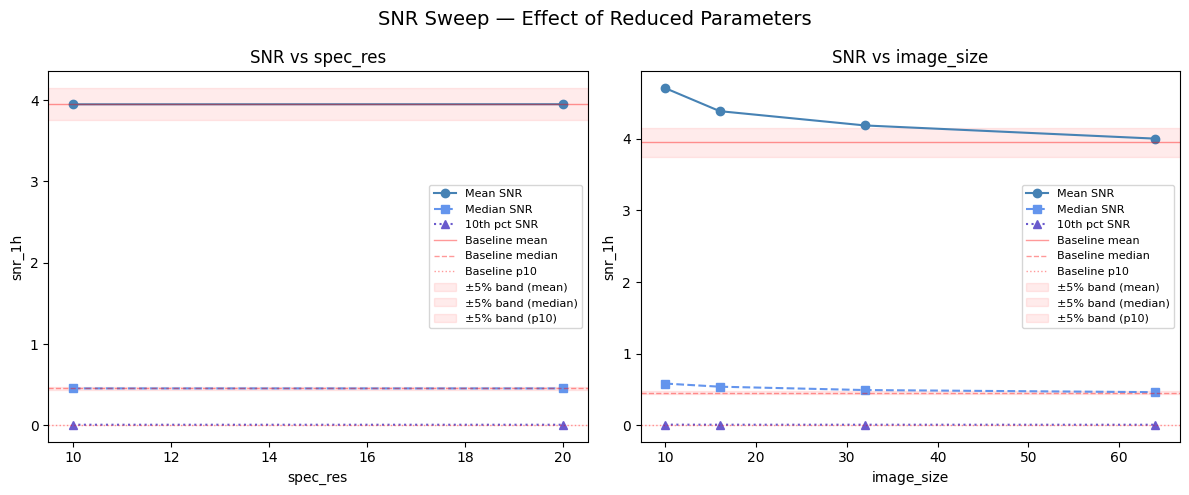

In [20]:
# Compute all three baseline stats once
snr_ref_mean   = snr_baseline.mean()
snr_ref_median = snr_baseline.median()
snr_ref_p10    = snr_baseline.quantile(0.10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("SNR Sweep — Effect of Reduced Parameters", fontsize=14)

tol = 0.05  # ±5% tolerance band

for ax, df, param, target in [
    (axes[0], df_res, "spec_res",   20),
    (axes[1], df_img, "image_size", 10),
]:
    # Sweep lines
    ax.plot(df[param], df["snr_mean"],   marker="o", label="Mean SNR",      color="steelblue")
    ax.plot(df[param], df["snr_median"], marker="s", label="Median SNR",    color="cornflowerblue", linestyle="--")
    ax.plot(df[param], df["snr_p10"],    marker="^", label="10th pct SNR",  color="slateblue",      linestyle=":")

    # Baseline reference lines — one per metric, matching colors
    ax.axhline(snr_ref_mean,   color="red",      linestyle="-",  linewidth=1.0, alpha=0.4, label="Baseline mean")
    ax.axhline(snr_ref_median, color="red", linestyle="--", linewidth=1.0, alpha=0.4, label="Baseline median")
    ax.axhline(snr_ref_p10,    color="red",      linestyle=":",  linewidth=1.0, alpha=0.4, label="Baseline p10")

    # Tolerance band around baseline mean
    ax.axhspan(snr_ref_mean * (1 - tol), snr_ref_mean * (1 + tol),
               alpha=0.08, color="red", label="±5% band (mean)")
    # Tolerance band around baseline median
    ax.axhspan(snr_ref_median * (1 - tol), snr_ref_median * (1 + tol),
               alpha=0.08, color="red", label="±5% band (median)")
    # Tolerance band around baseline p10
    ax.axhspan(snr_ref_p10 * (1 - tol), snr_ref_p10 * (1 + tol),
               alpha=0.08, color="red", label="±5% band (p10)")
    
    ax.set_xlabel(param)
    ax.set_ylabel("snr_1h")
    ax.set_title(f"SNR vs {param}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## sweeping combined values

In [ ]:
def run_2d_sweep(spec_res_values, image_size_values):
    """
    Sweep both parameters together as a grid.
    Returns a DataFrame with one row per (spec_res, image_size) combination.
    """
    results = []
    total = len(spec_res_values) * len(image_size_values)
    i = 0

    for res in spec_res_values:
        for img in image_size_values:
            bus.data.options.set_manual(spec_res=res, image_size=img)
            instrument.apply_options()
            instrument.get_snr()

            snr_values = bus.data.catalog["snr_1h"].copy()

            results.append({
                "spec_res":   res,
                "image_size": img,
                "snr_mean":   snr_values.mean(),
                "snr_median": snr_values.median(),
                "snr_p10":    snr_values.quantile(0.10),
            })

            i += 1
            print(f"[{i}/{total}] spec_res={res}, image_size={img} → mean SNR={results[-1]['snr_mean']:.3f}")

    return pd.DataFrame(results)

In [ ]:
df_2d = run_2d_sweep(
    spec_res_values  = [5, 10, 20, 30, 50, 75, 100],
    image_size_values= [4, 8, 10, 16, 32, 64, 128, 256],
)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("SNR 2D Sweep — spec_res x image_size", fontsize=14)

for ax, metric, title in [
    (axes[0], "snr_mean",   "Mean SNR"),
    (axes[1], "snr_median", "Median SNR"),
    (axes[2], "snr_p10",    "10th Percentile SNR"),
]:
    pivot = df_2d.pivot(index="spec_res", columns="image_size", values=metric)

    sns.heatmap(
        pivot,
        ax=ax,
        annot=True, fmt=".2f",
        cmap="viridis",
        cbar_kws={"label": "snr_1h"},
        linewidths=0.4,
    )

    # Mark the target cell
    res_idx   = list(pivot.index).index(20)   if 20   in pivot.index.tolist()   else None
    img_idx   = list(pivot.columns).index(10) if 10   in pivot.columns.tolist() else None
    if res_idx is not None and img_idx is not None:
        ax.add_patch(plt.Rectangle(
            (img_idx, res_idx), 1, 1,
            fill=False, edgecolor="red", lw=2.5, label="Target (res=20, img=10)"
        ))

    ax.set_title(title)
    ax.set_xlabel("image_size")
    ax.set_ylabel("spec_res")

plt.tight_layout()
plt.savefig("sweep_2d_heatmap.png", dpi=150)
plt.show()

# spectrum comparison

## reference

In [7]:
prefactor = (integration_time 
             * bus.data.inst['eff_tot'] 
             * bus.data.inst['telescope_area'] 
             * bus.data.inst['wl_bin_widths'])

In [8]:
spectrum, flux_planet, noise = instrument.get_spectrum(temp_s=5778,  # star temperature in K
                                                    radius_s=1,  # star radius in solar radii
                                                    distance_s=10,  # distance to system in pc
                                                    lat_s=0.78,  # ecliptic latitude of observation in rad
                                                    z=3,  # zodi level
                                                    angsep=0.1,  # angular separation of planet in arcsec
                                                    flux_planet_spectrum=[lam_lifesim, f_lifesim],
                                                    safe_mode=True,
                                                    integration_time=integration_time)

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_85501/2342845030.py:3: SyntaxWarning: invalid escape sequence '\c'
  ln2 = plt.plot(spectrum[0], flux_planet / prefactor, c='tab:cyan', label='LIFEsim spectrum $\cdot$ throughput')


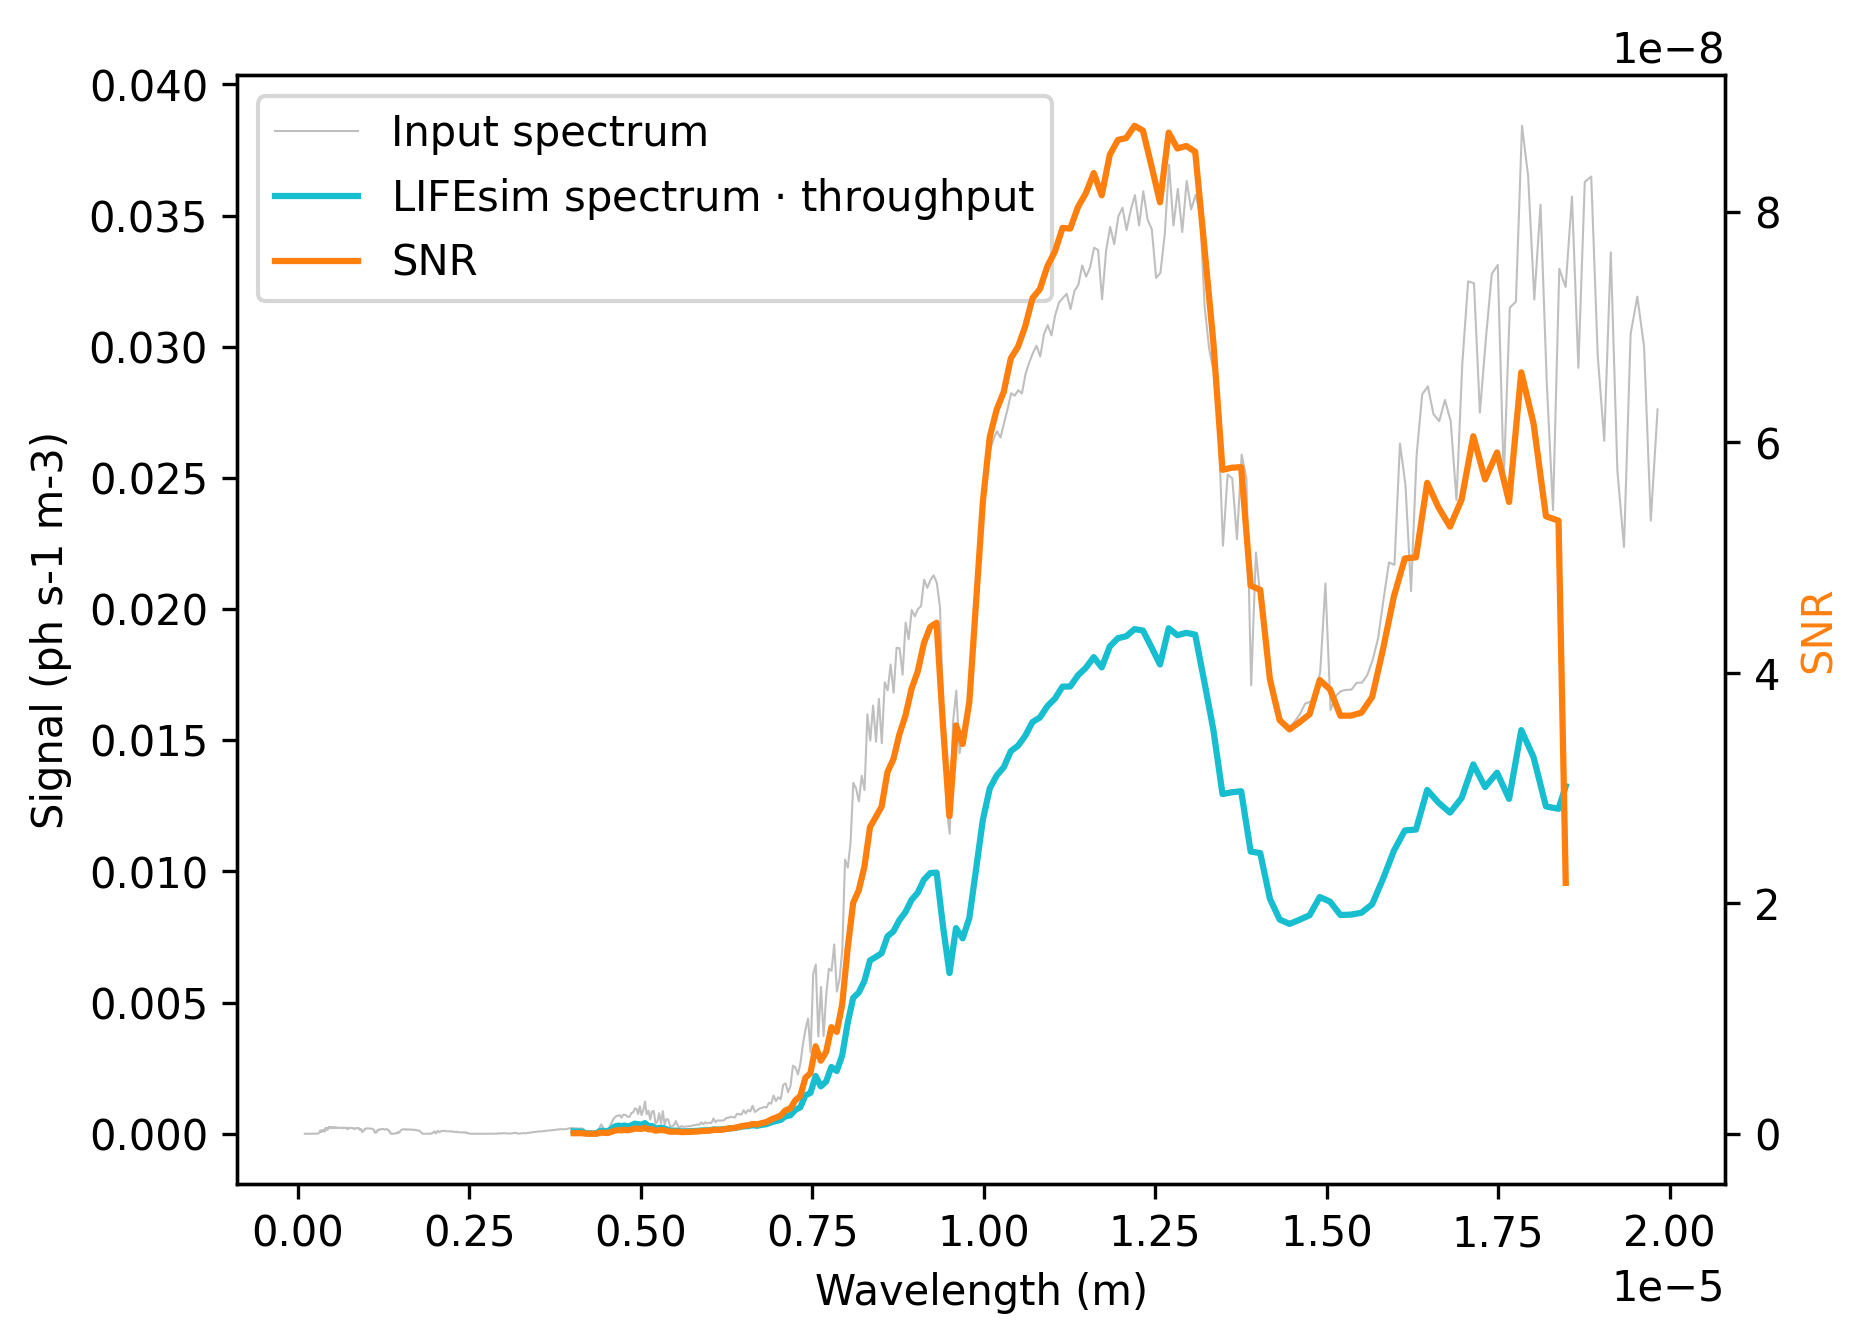

In [9]:
fig, ax = plt.subplots(dpi=300)
ln1 = plt.plot(lam_lifesim, f_lifesim, lw=0.5, c='gray', alpha=0.5, label='Input spectrum')
ln2 = plt.plot(spectrum[0], flux_planet / prefactor, c='tab:cyan', label='LIFEsim spectrum $\cdot$ throughput')
ax2=ax.twinx()
ln3 = ax2.plot(spectrum[0], spectrum[1],c='tab:orange', label='SNR')

lns = ln1 + ln2 + ln3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)

ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph s-1 m-3)')
ax2.set_ylabel("SNR",c='tab:orange')
plt.show()

## sweeps

In [10]:
def run_spectrum_sweep(param_name: str, sweep_values: list, fixed_params: dict):
    """
    Sweep one parameter (e.g. 'spec_res' or 'image_size'), keep others fixed.
    Returns a dict keyed by sweep value, each containing spectrum, flux_planet, noise.
    """
    results = {}

    for val in sweep_values:
        bus.data.options.set_manual(**{**fixed_params, param_name: val})
        instrument.apply_options()

        prefactor = (integration_time 
                    * bus.data.inst['eff_tot'] 
                    * bus.data.inst['telescope_area'] 
                    * bus.data.inst['wl_bin_widths'])

        spectrum, flux_planet, noise = instrument.get_spectrum(
            temp_s=5778,
            radius_s=1,
            distance_s=10,
            lat_s=0.78,
            z=3,
            angsep=0.1,
            flux_planet_spectrum=[lam_lifesim, f_lifesim],
            safe_mode=True,
            integration_time=integration_time
        )

        results[val] = {
            'spectrum':     spectrum,
            'flux_planet':  flux_planet,
            'noise':        noise,
            'prefactor':      prefactor,
        }
    return results

In [11]:
results = run_spectrum_sweep(
    param_name   = "spec_res",
    sweep_values = np.concatenate([[3, 5, 7], np.arange(10, 160, 10)]),
    fixed_params = {"image_size": 256},
)

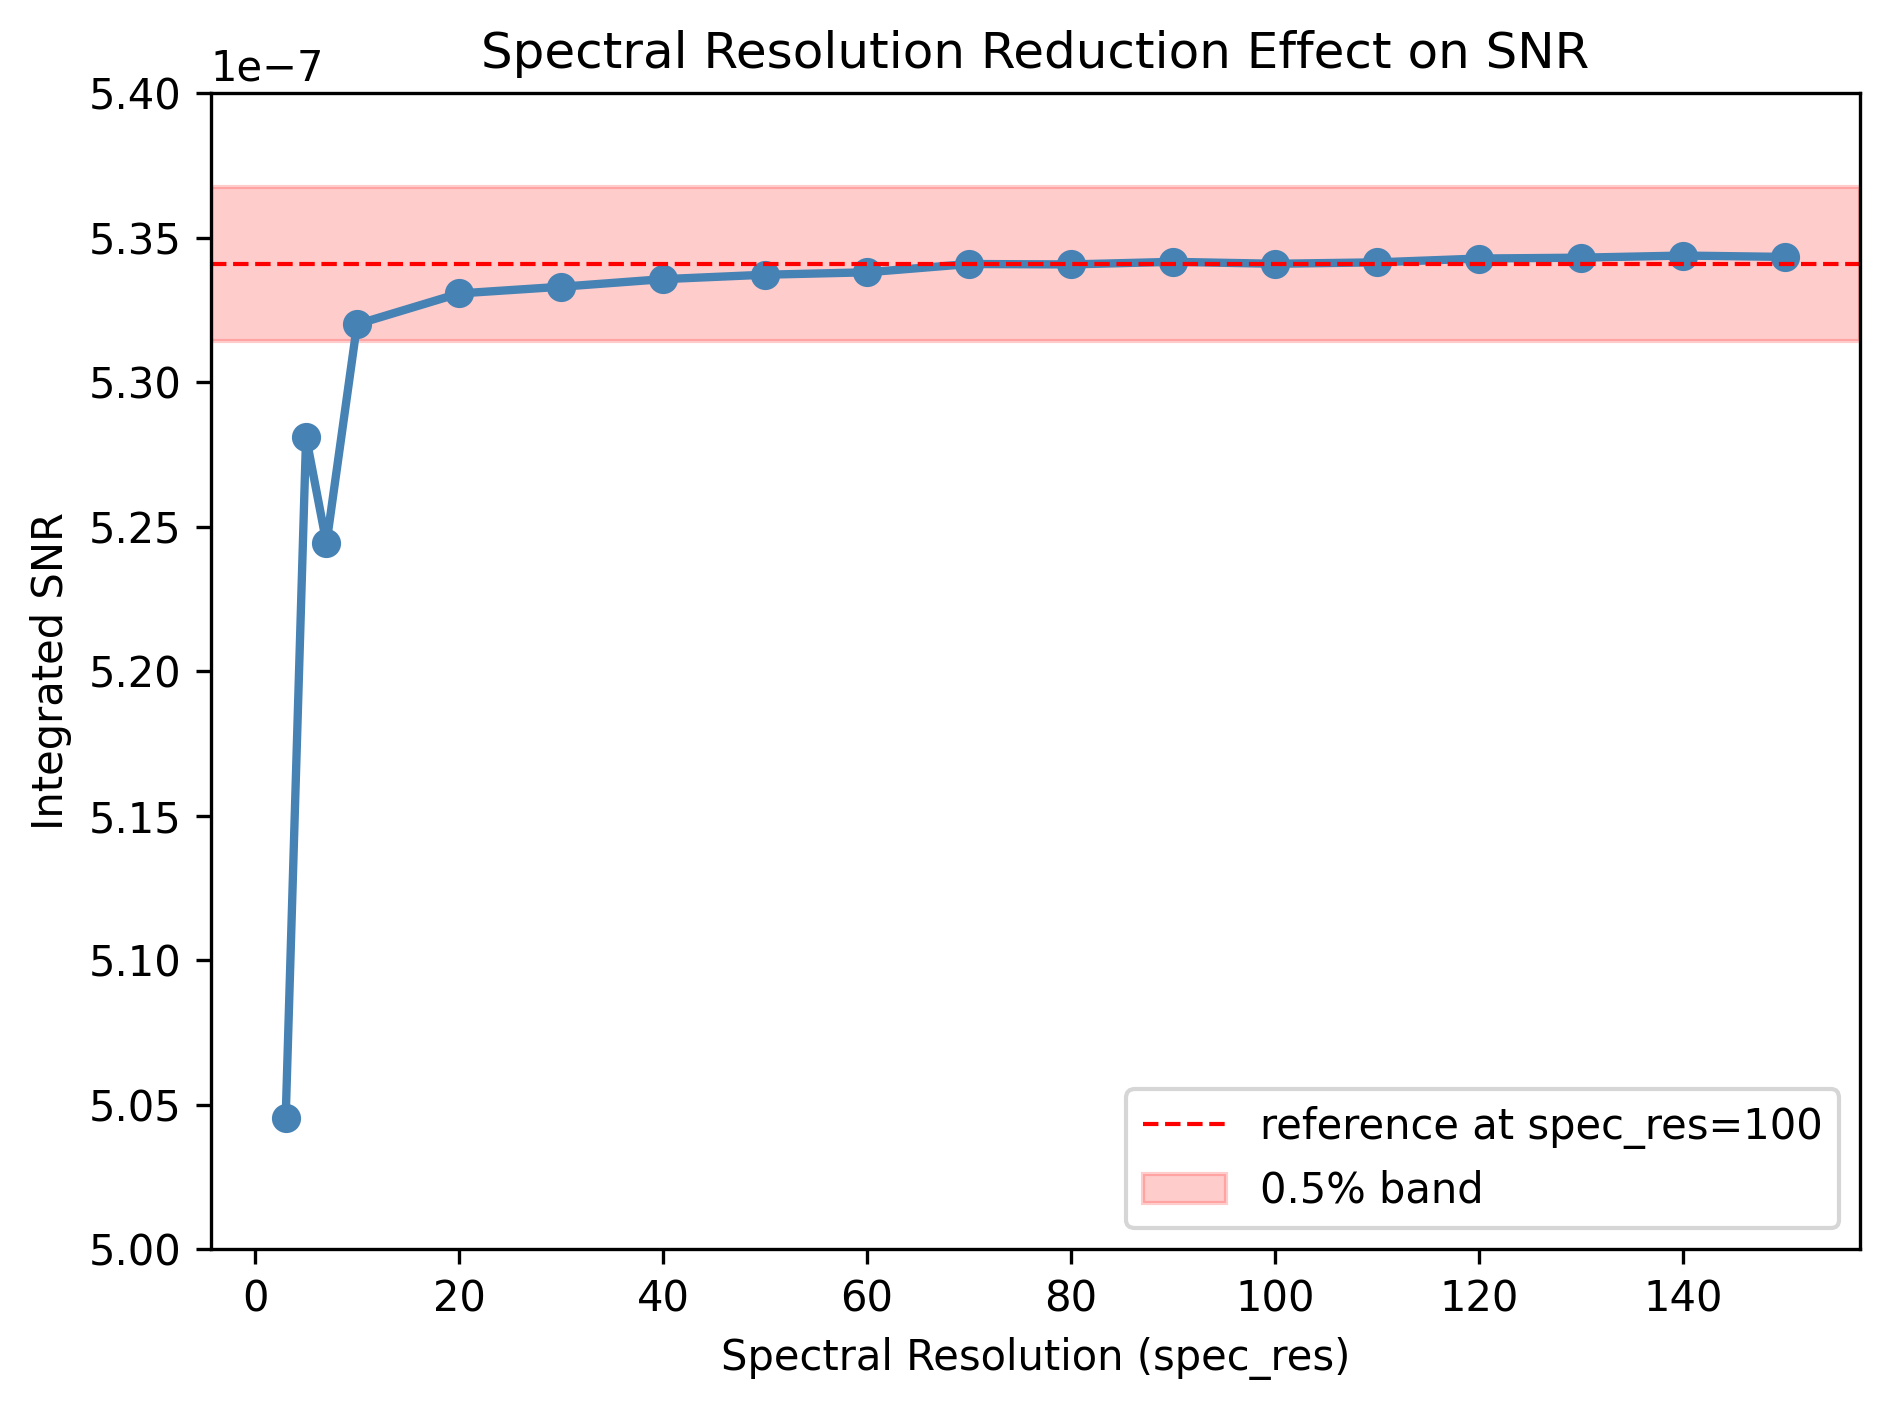

In [12]:
fig, ax = plt.subplots(dpi=300)

spec_res_vals = []
snr_vals = []

# Get the SNR value for spec_res=100
snr_at_100 = results[100]['spectrum'][1]
snr_value_100 = np.sqrt(np.sum(snr_at_100**2))

for val, data in results.items():
    spec_res_vals.append(val)
    snr_vals.append(np.sqrt(np.sum(data['spectrum'][1]**2)))

ax.plot(spec_res_vals, snr_vals, marker='o', color='steelblue', linewidth=2)
ax.axhline(snr_value_100, color='red', linestyle='--', linewidth=1, label='reference at spec_res=100')
tol = 0.005
ax.axhspan(snr_value_100 * (1 - tol), snr_value_100 * (1 + tol),
           alpha=0.2, color='red', label='0.5% band')

ax.set_ylim(5e-7, 5.4e-7)

ax.legend()
ax.set_xlabel('Spectral Resolution (spec_res)')
ax.set_ylabel('Integrated SNR')
ax.set_title('Spectral Resolution Reduction Effect on SNR')
plt.tight_layout()
plt.show()

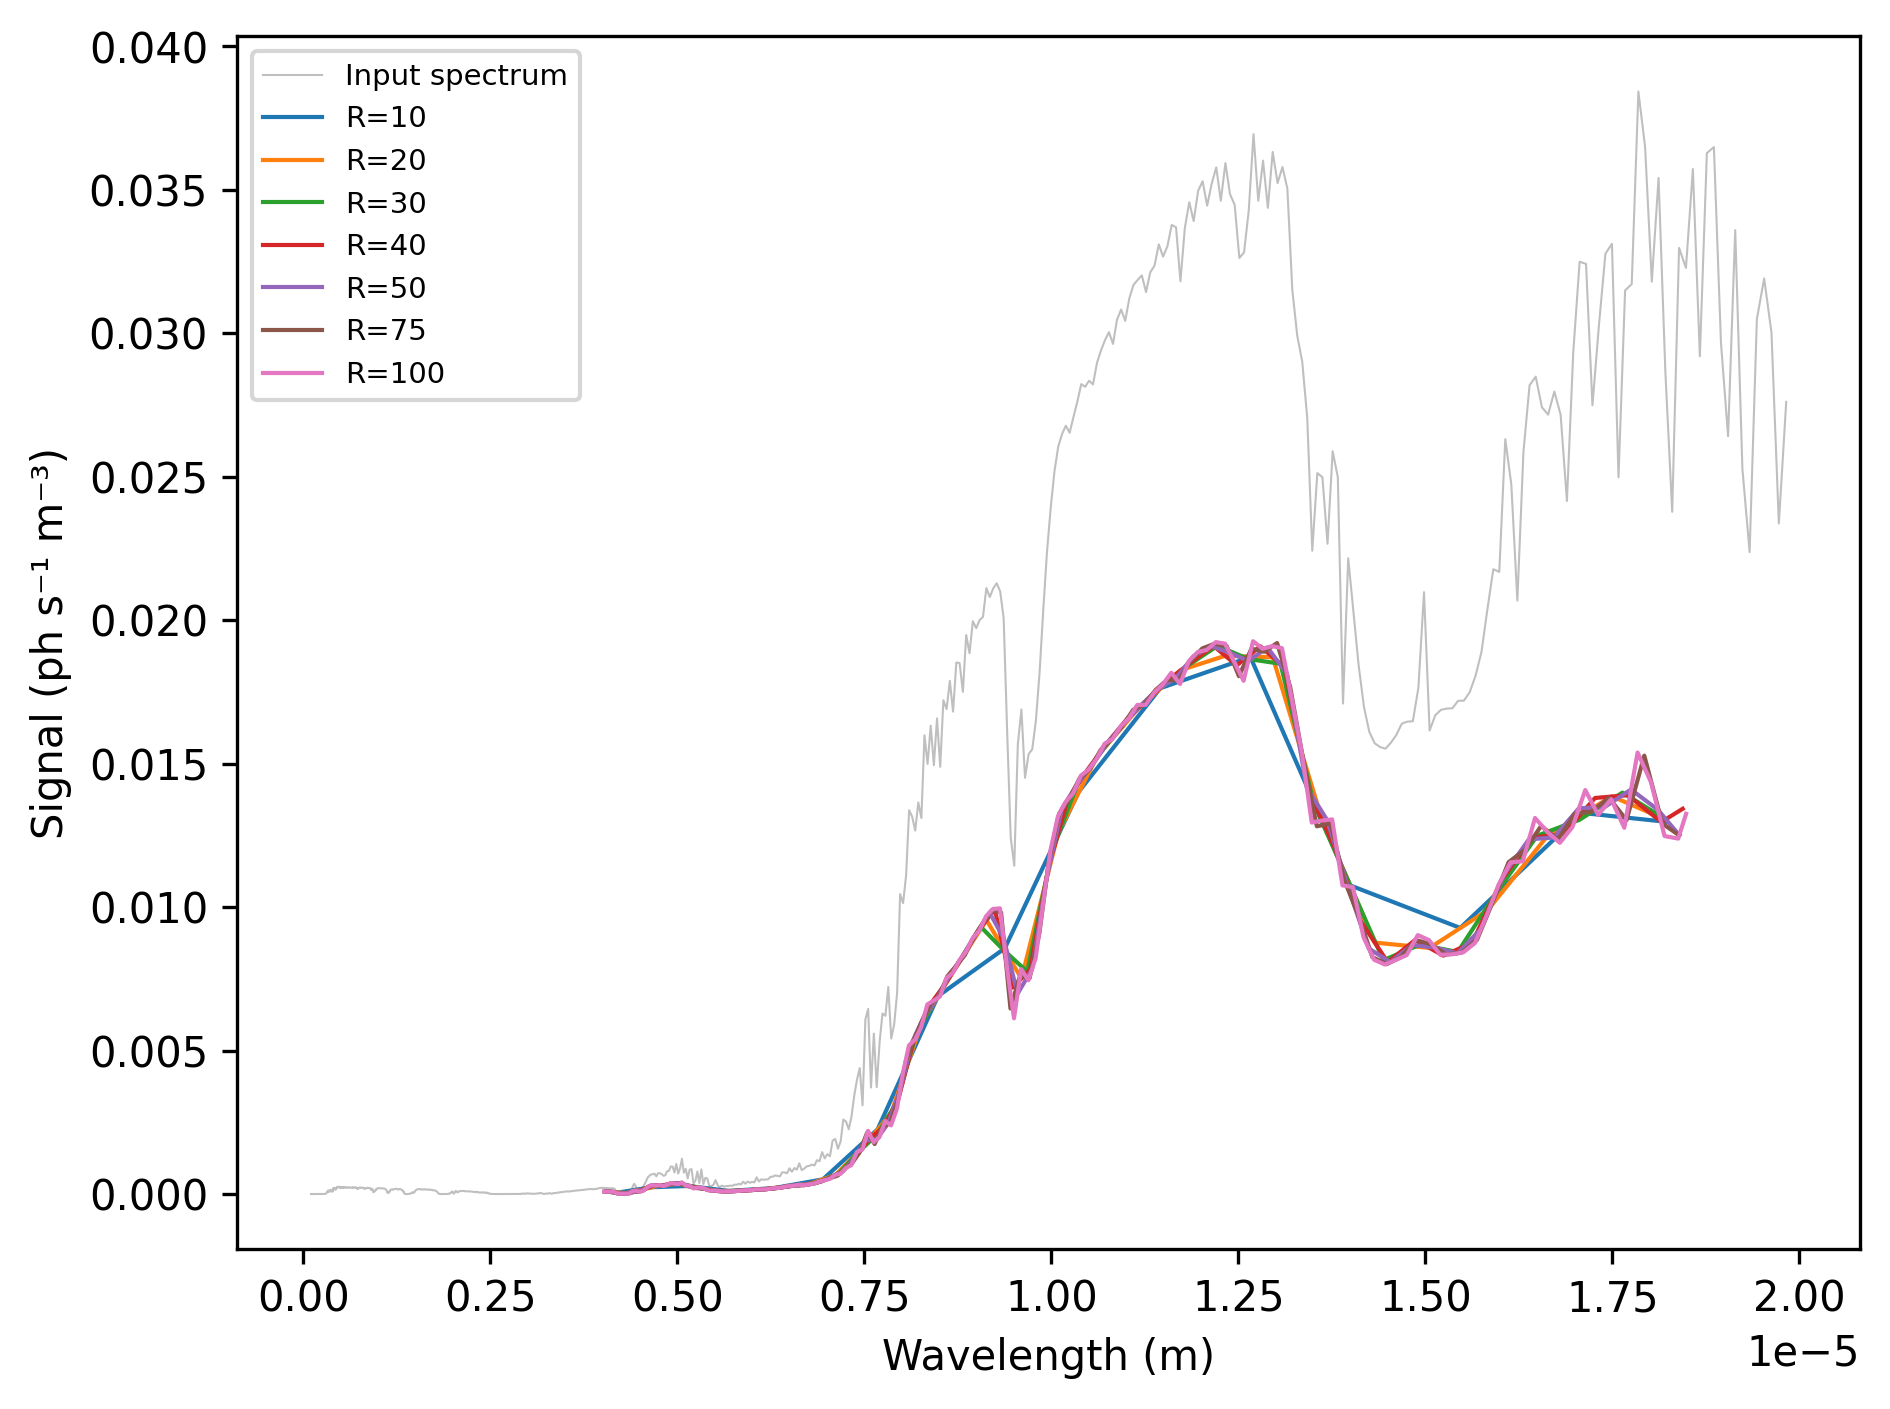

In [12]:
fig, ax = plt.subplots(dpi=300)

ax.plot(lam_lifesim, f_lifesim, lw=0.5, c='gray', alpha=0.5, label='Input spectrum')


for val, data in results.items():
    ax.plot(data['spectrum'][0], data['flux_planet'] / data['prefactor'],
            lw=1, label=f'R={val}')

ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph s⁻¹ m⁻³)')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

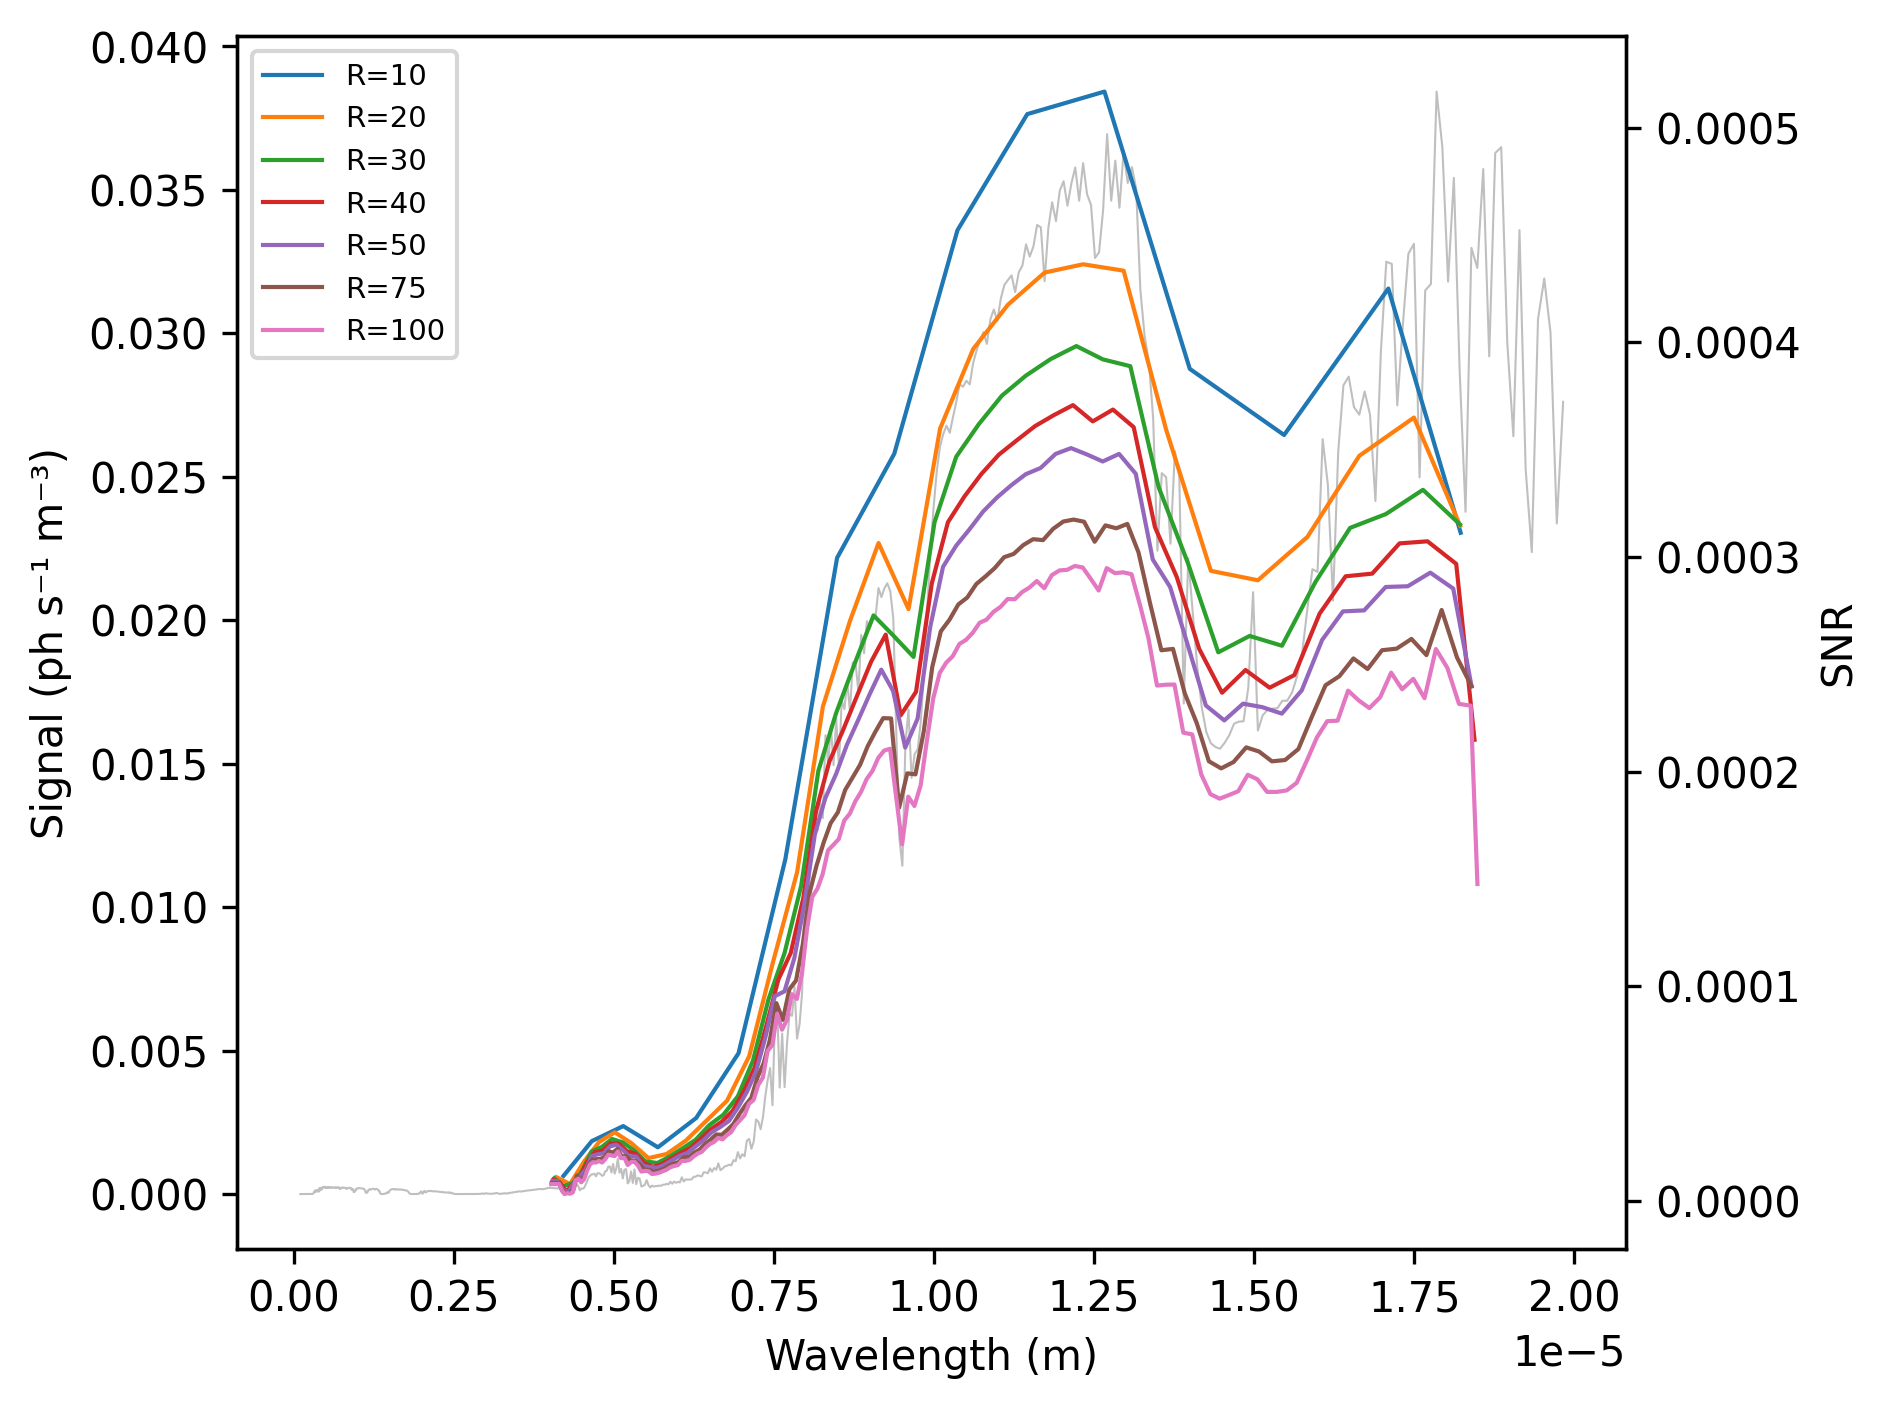

In [13]:
fig, ax = plt.subplots(dpi=300)

ax.plot(lam_lifesim, f_lifesim, lw=0.5, c='gray', alpha=0.5, label='Input spectrum')

ax2=ax.twinx()
for val, data in results.items():
    ax2.plot(data['spectrum'][0], np.sqrt(data['spectrum'][1]),
            lw=1, label=f'R={val}')

ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph s⁻¹ m⁻³)')
ax2.set_ylabel('SNR')
#ax2.set_ylim(-0e-8, 9e-8)
ax2.legend(fontsize=7, loc='upper left')
plt.tight_layout()
plt.show()

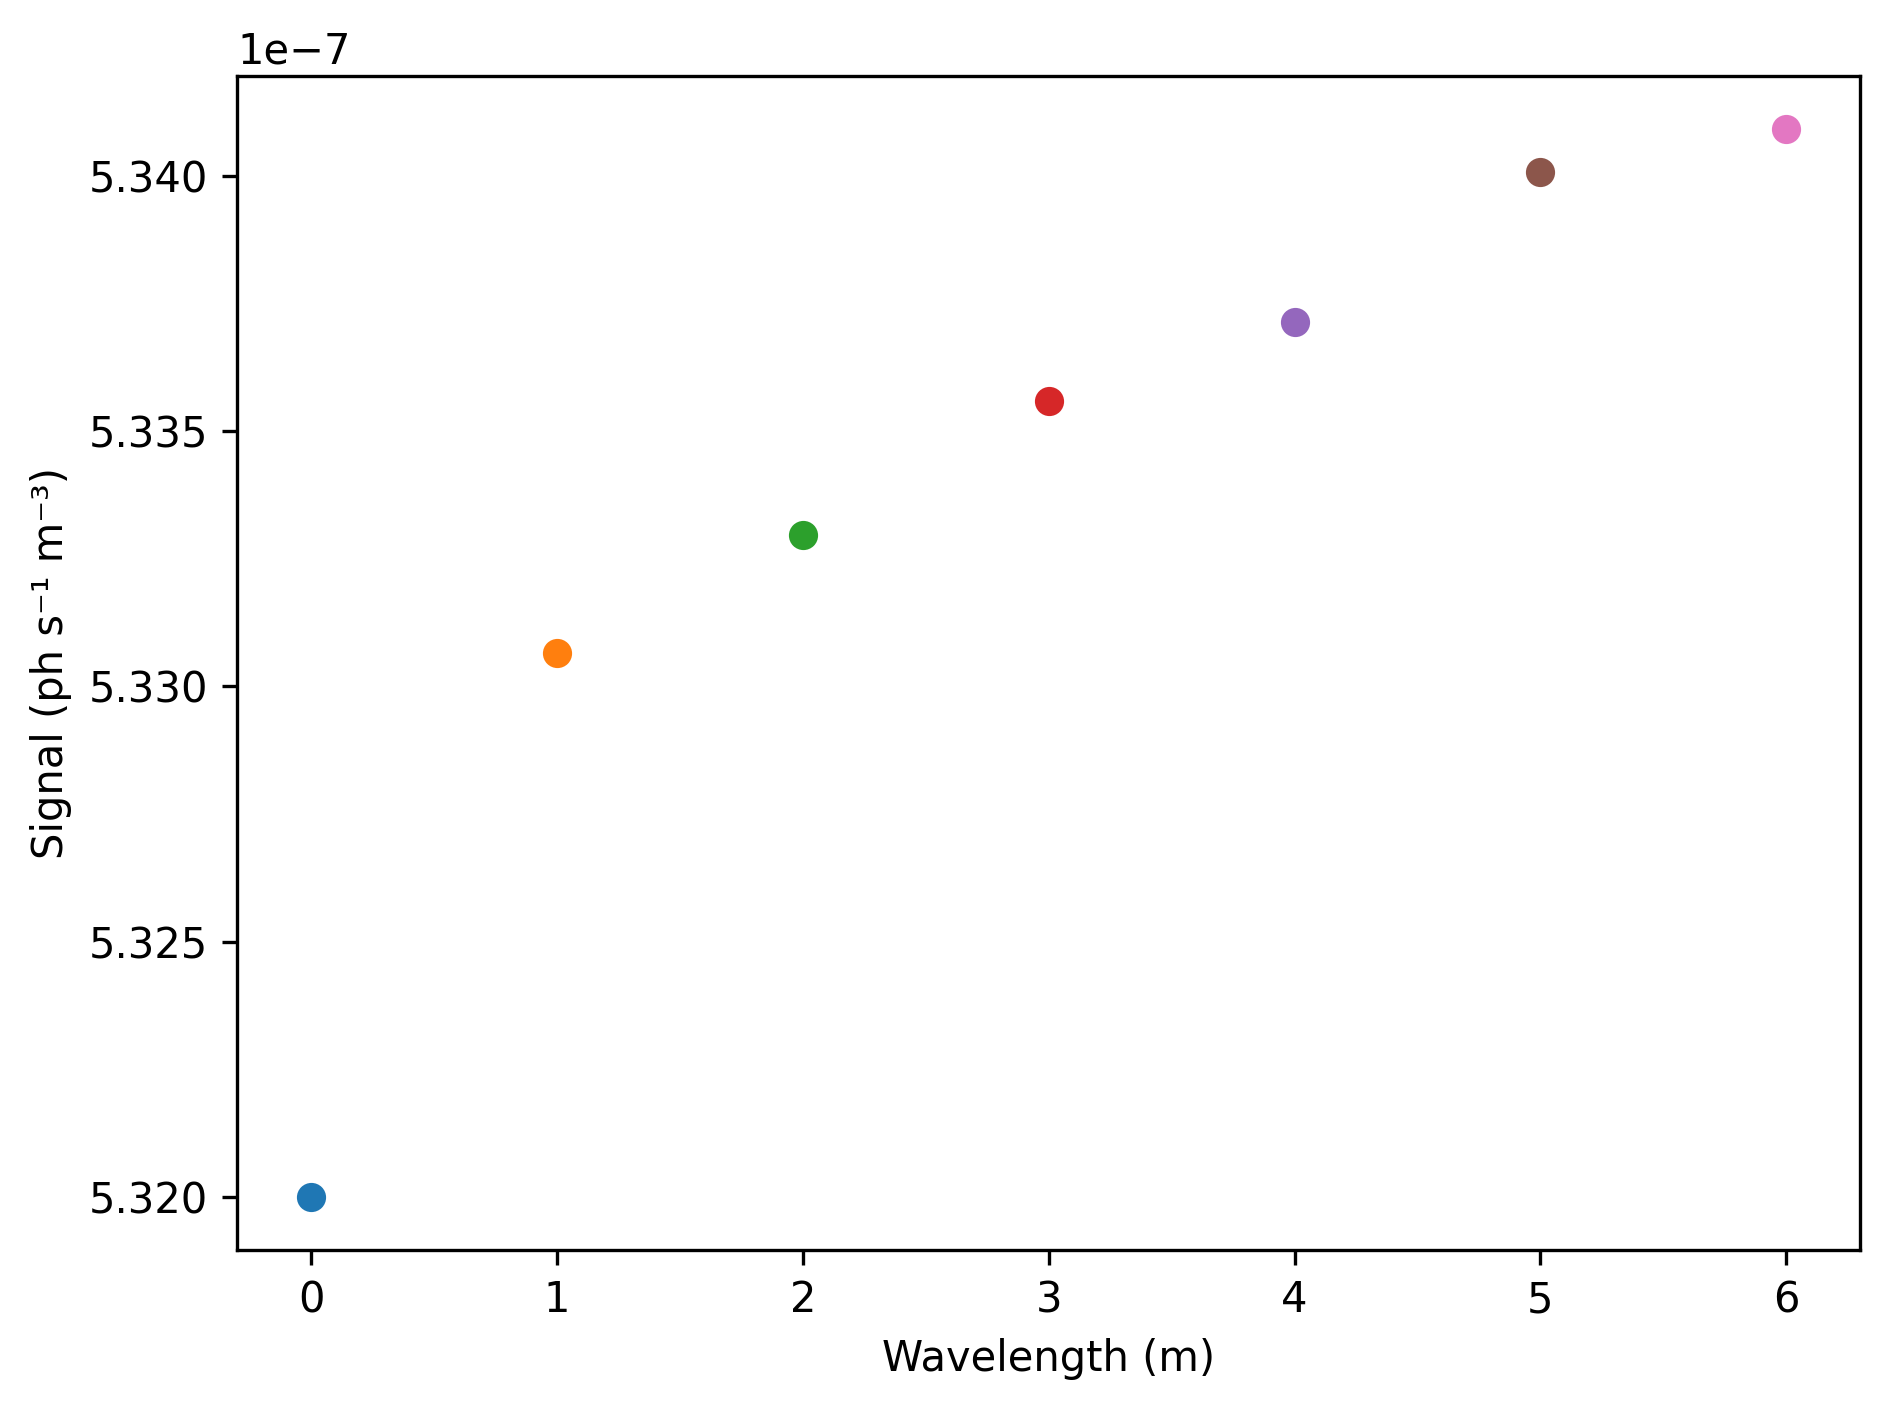

In [14]:
fig, ax = plt.subplots(dpi=300)

a = 0
for val, data in results.items():
    ax.scatter(a, np.sqrt(np.sum(data['spectrum'][1]**2)),
            lw=1, label=f'R={val}')
    a += 1

ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph s⁻¹ m⁻³)')
ax2.set_ylabel('SNR')
#ax2.set_ylim(-0e-8, 9e-8)
ax2.legend(fontsize=7, loc='upper left')
plt.tight_layout()
plt.show()

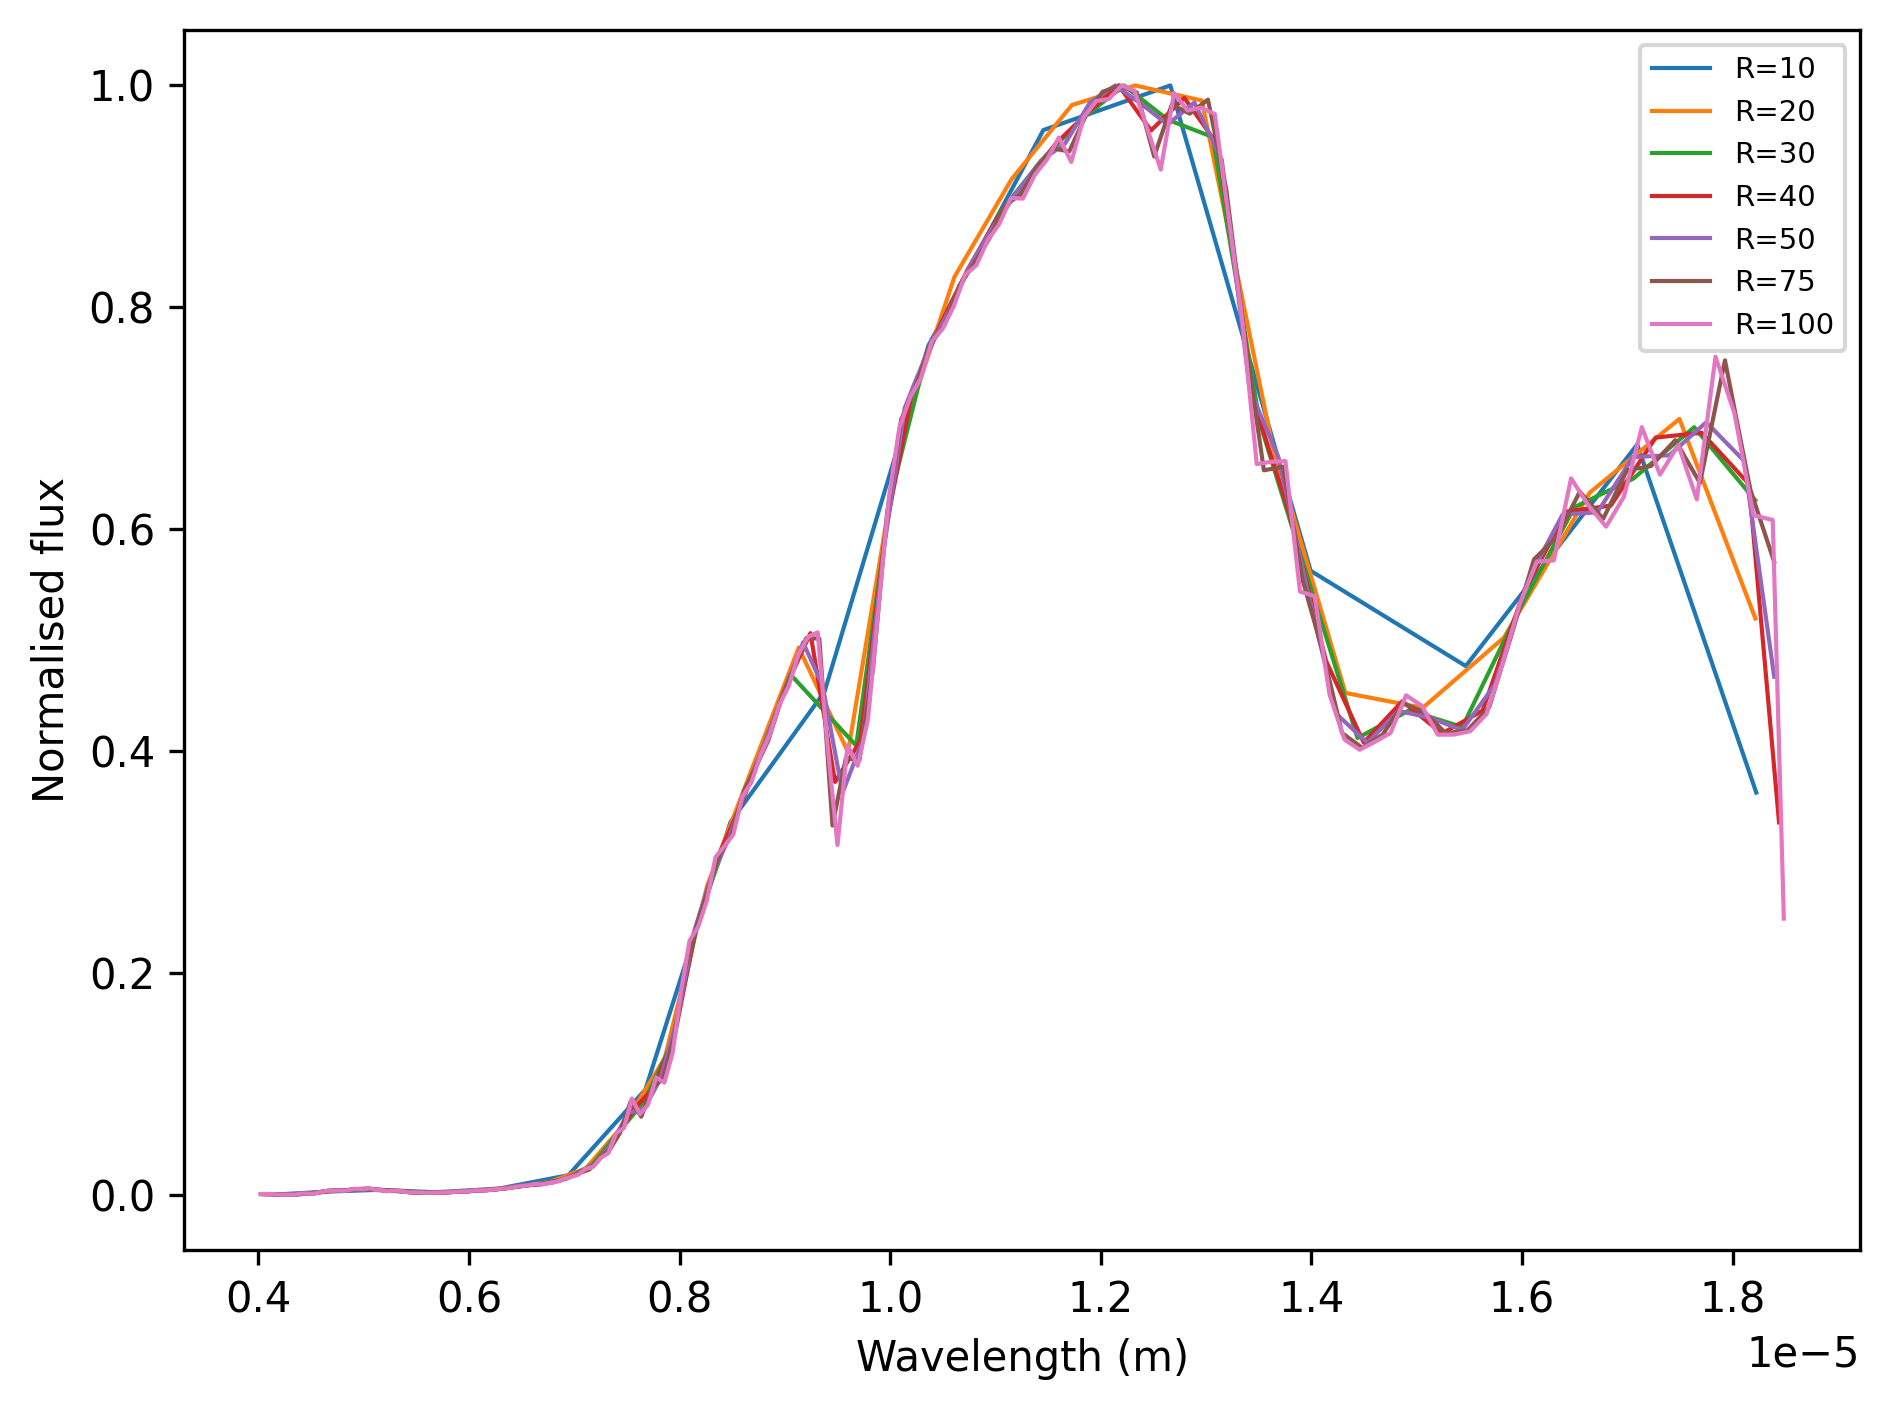

In [17]:
fig, ax = plt.subplots(dpi=300)
for val, data in results.items():
    flux = data['spectrum'][1]
    flux_norm = flux / np.nanmax(flux)
    ax.plot(data['spectrum'][0], flux_norm, lw=1, label=f'R={val}')

ax.set_ylabel('Normalised flux')
ax.set_xlabel('Wavelength (m)')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [15]:
results2 = run_spectrum_sweep(
    param_name="image_size",
    sweep_values=[4, 6, 8, 12, 16, 24, 32, 48, 64, 96, 128, 192, 256, 384, 512],
    fixed_params={"spec_res": 100},
)

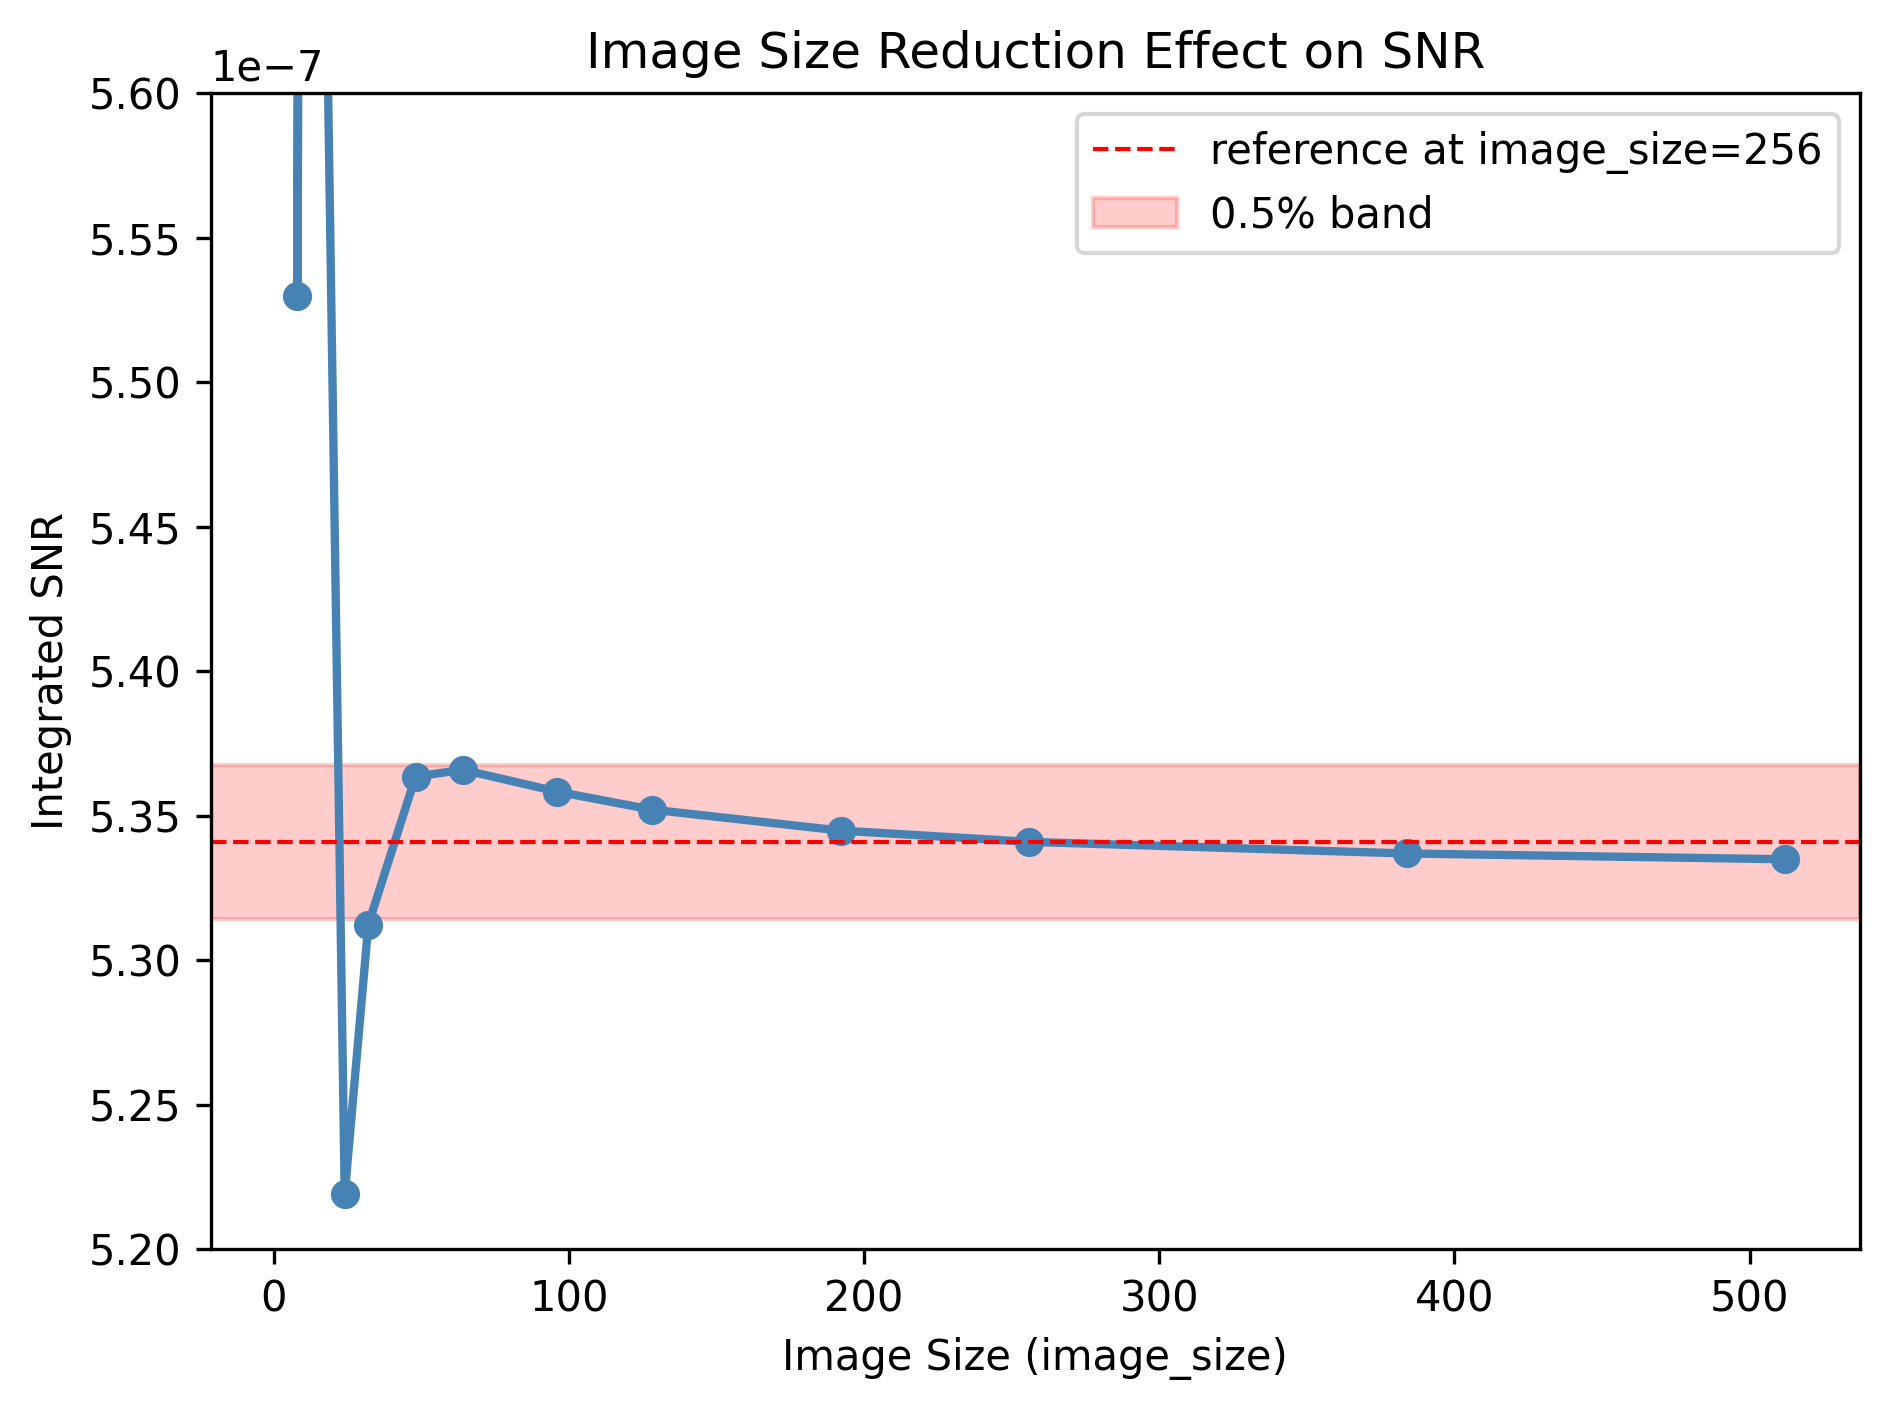

In [24]:
fig, ax = plt.subplots(dpi=300)

spec_res_vals = []
snr_vals = []

# Get the SNR value for image_size=256
snr_at_256 = results2[256]['spectrum'][1]
snr_value_256 = np.sqrt(np.sum(snr_at_256**2))

for val, data in results2.items():
    spec_res_vals.append(val)
    snr_vals.append(np.sqrt(np.sum(data['spectrum'][1]**2)))

ax.plot(spec_res_vals, snr_vals, marker='o', color='steelblue', linewidth=2)
ax.axhline(snr_value_256, color='red', linestyle='--', linewidth=1, label='reference at image_size=256')
tol = 0.005
ax.axhspan(snr_value_256 * (1 - tol), snr_value_256 * (1 + tol),
           alpha=0.2, color='red', label='0.5% band')

ax.set_ylim(5.2e-7, 5.6e-7)

ax.legend()
ax.set_xlabel('Image Size (image_size)')
ax.set_ylabel('Integrated SNR')
ax.set_title('Image Size Reduction Effect on SNR')
plt.tight_layout()
plt.show()

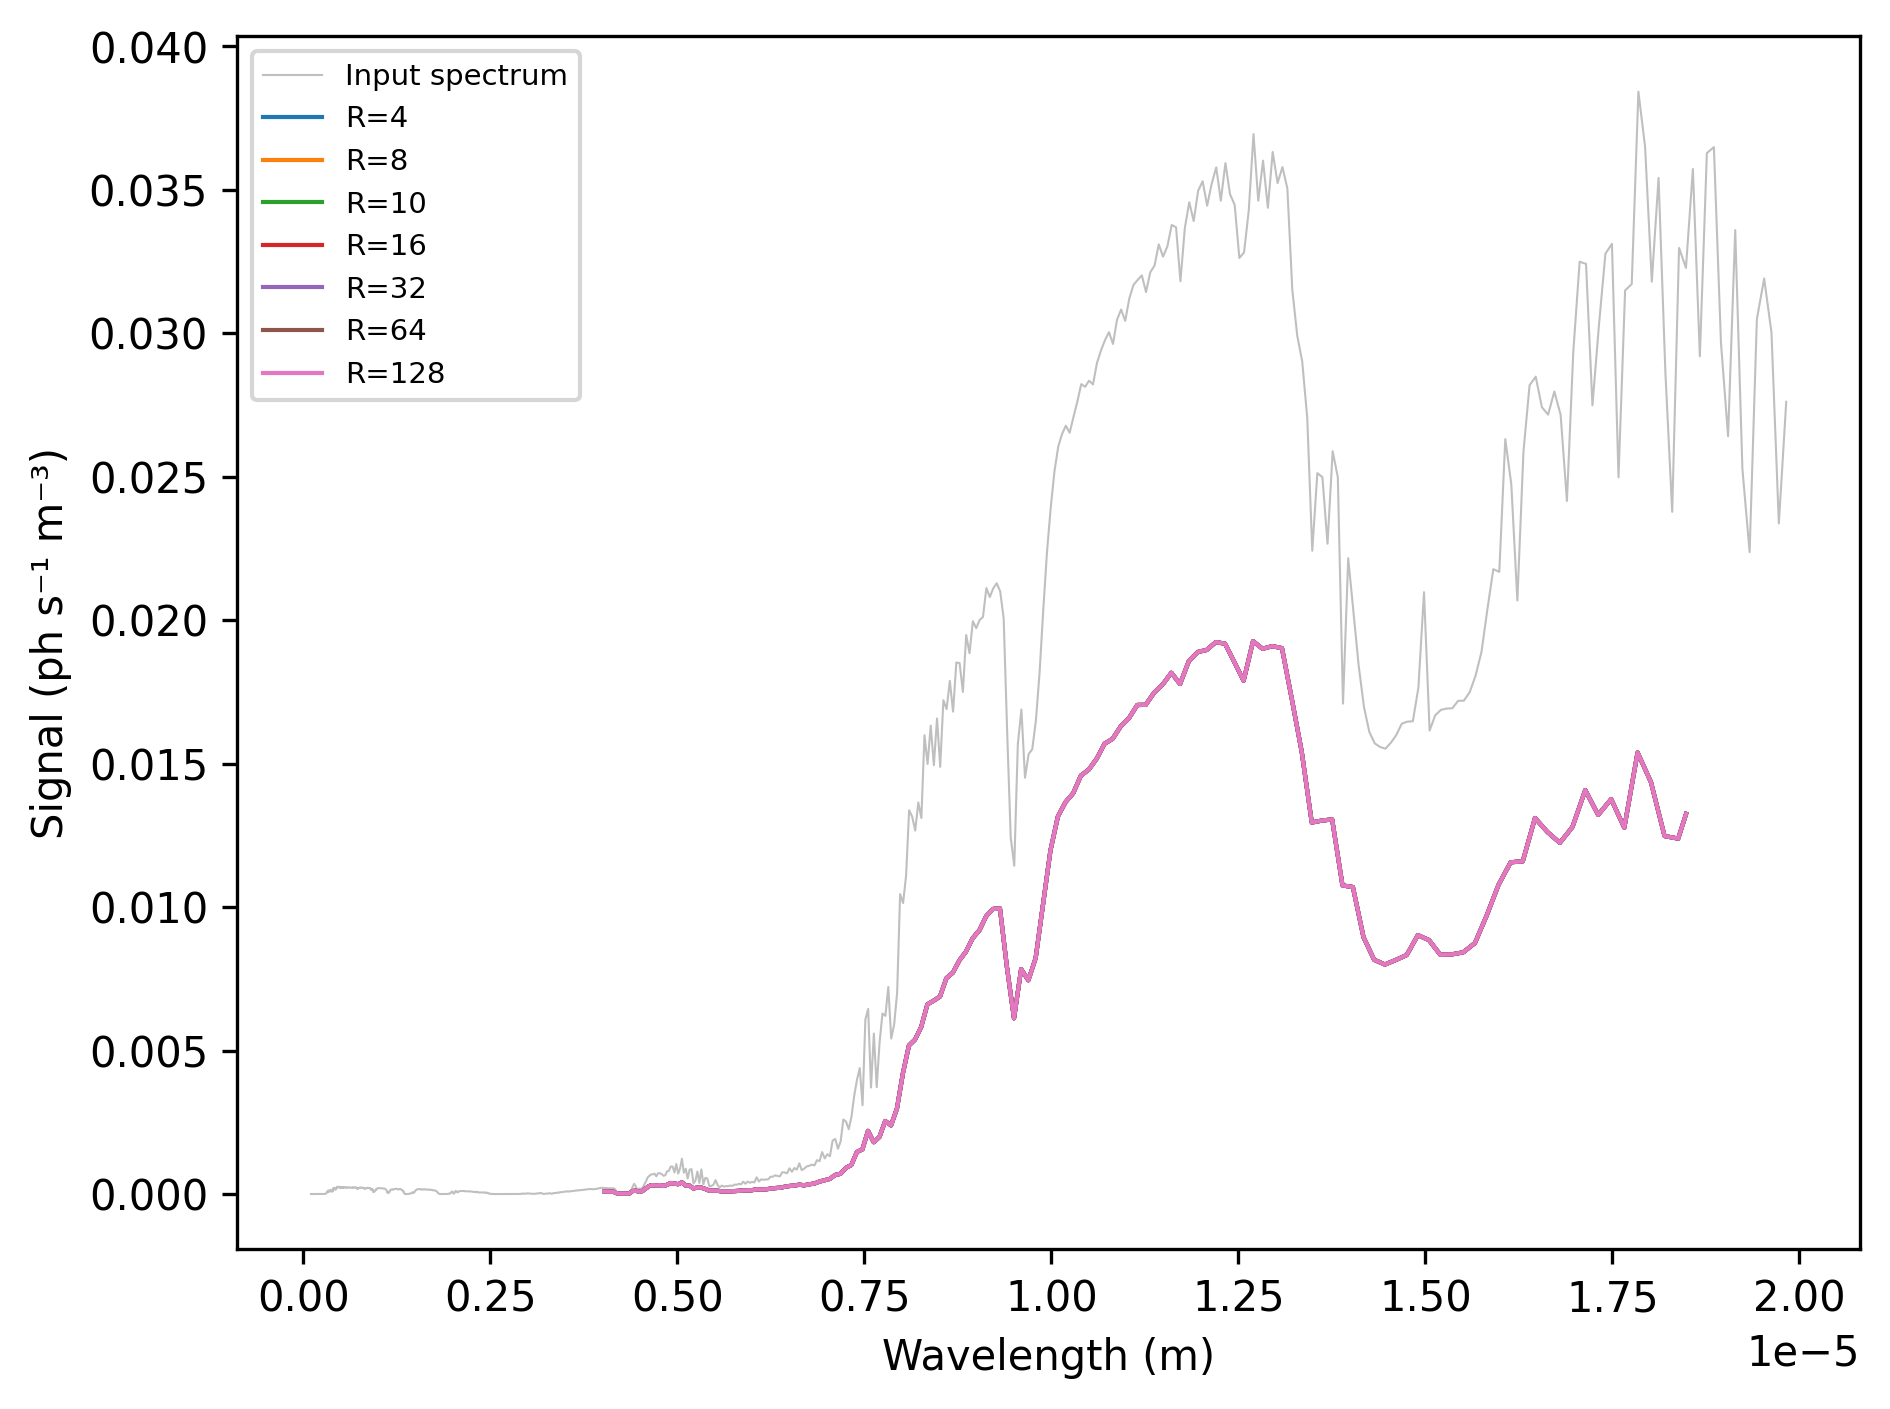

In [123]:
fig, ax = plt.subplots(dpi=300)

ax.plot(lam_lifesim, f_lifesim, lw=0.5, c='gray', alpha=0.5, label='Input spectrum')


for val, data in results2.items():
    ax.plot(data['spectrum'][0], data['flux_planet'] / data['prefactor'],
            lw=1, label=f'R={val}')

ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph s⁻¹ m⁻³)')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

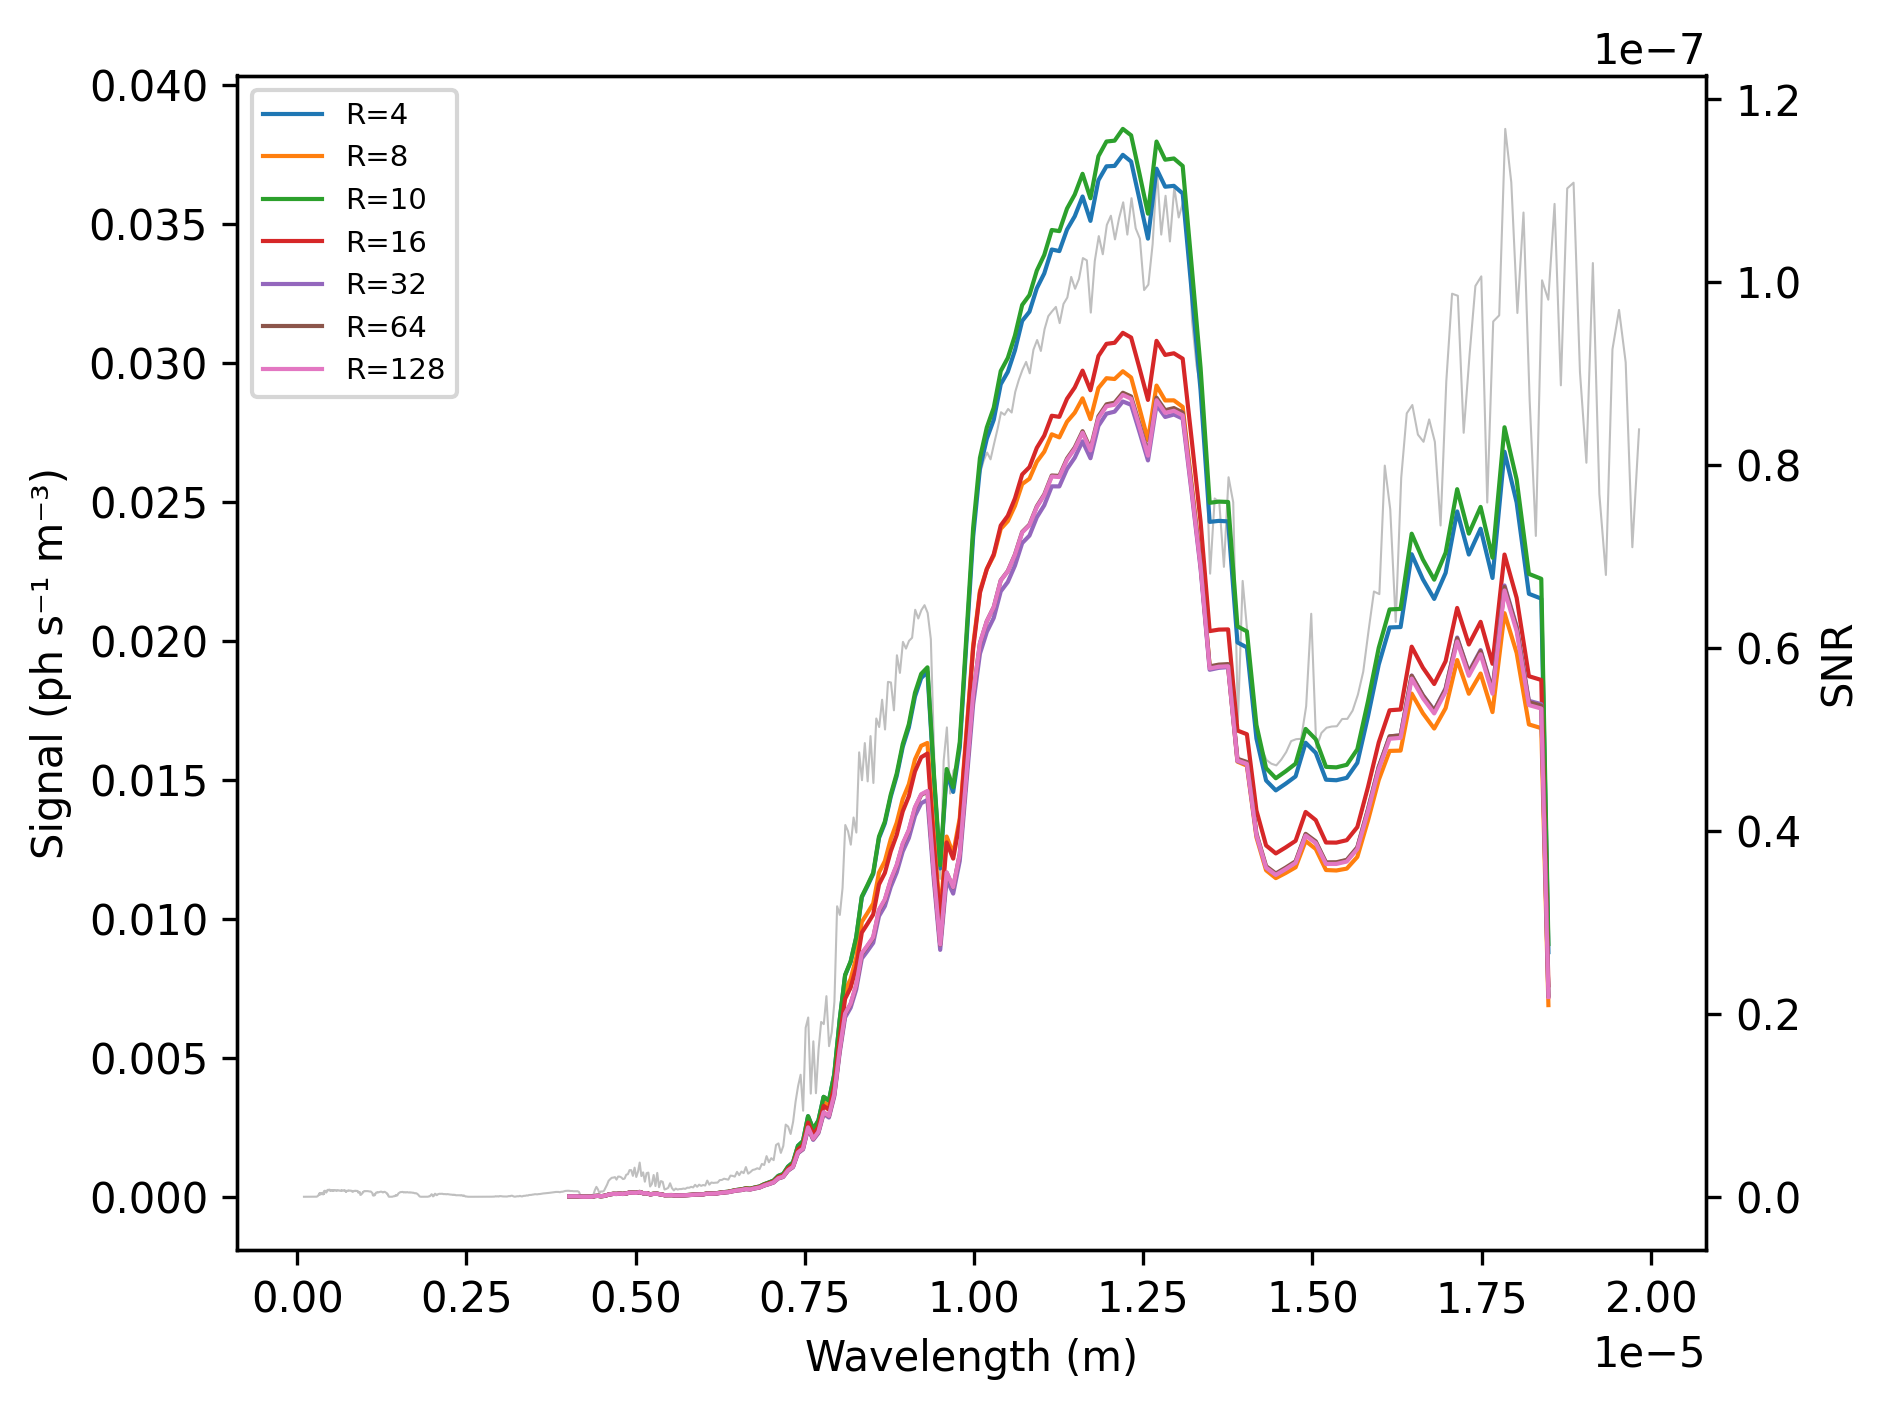

In [124]:
fig, ax = plt.subplots(dpi=300)

ax.plot(lam_lifesim, f_lifesim, lw=0.5, c='gray', alpha=0.5, label='Input spectrum')

ax2=ax.twinx()
for val, data in results2.items():
    ax2.plot(data['spectrum'][0], data['spectrum'][1],
            lw=1, label=f'R={val}')

ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph s⁻¹ m⁻³)')
ax2.set_ylabel('SNR')
# ax2.set_ylim(-0.1e-8, 1.3e-8)
ax2.legend(fontsize=7, loc='upper left')
plt.tight_layout()
plt.show()

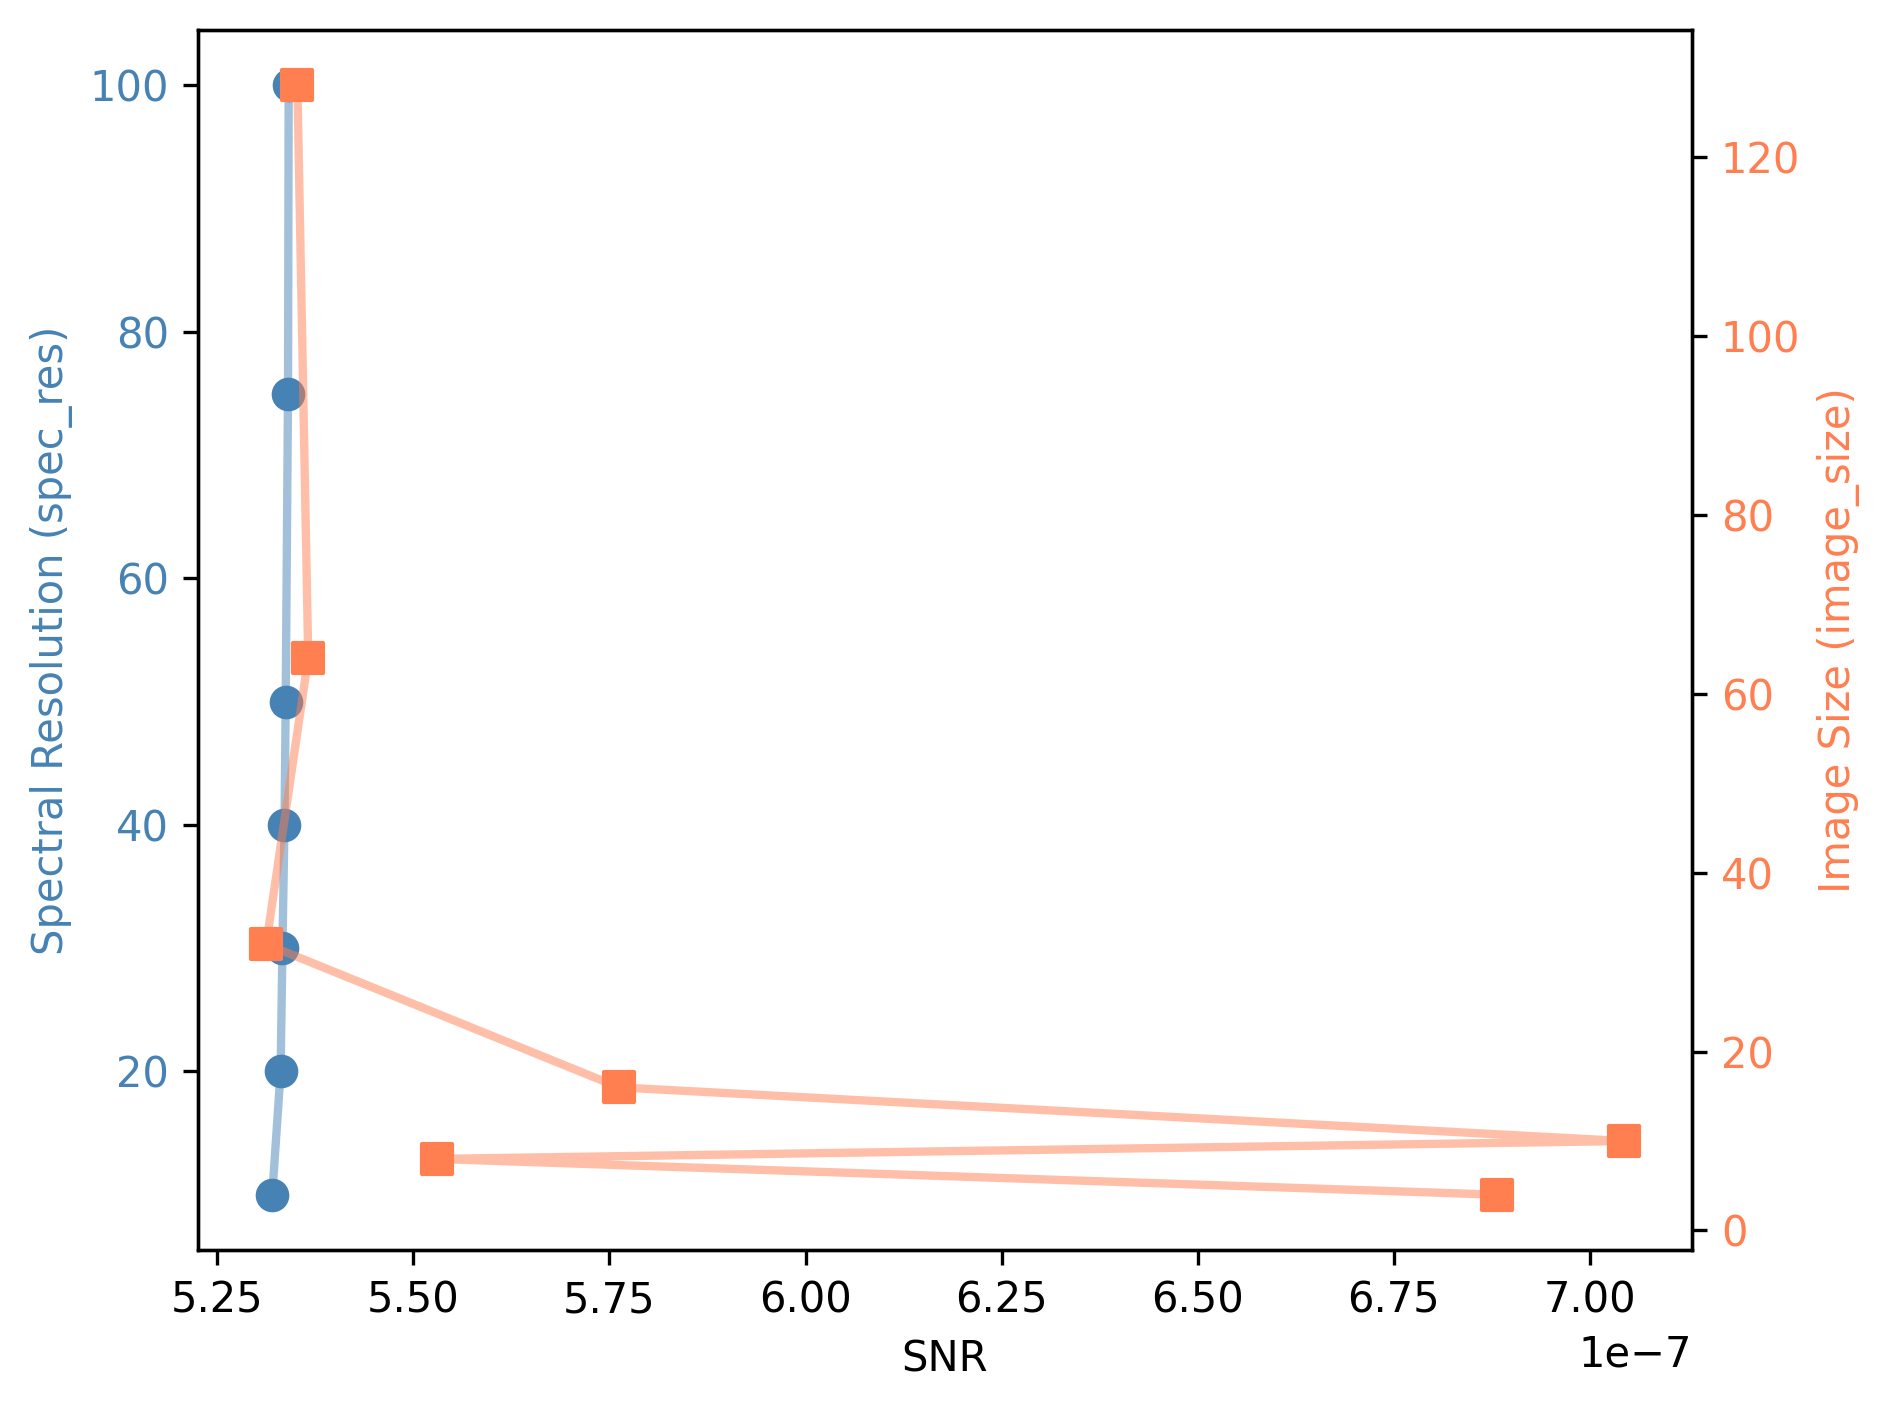

In [23]:
fig, ax1 = plt.subplots(dpi=300)

# Plot results (spec_res sweep) on left y-axis
spec_res_vals = []
snr_vals = []
for val, data in results.items():
    spec_res_vals.append(val)
    snr_vals.append(np.sqrt(np.sum(data['spectrum'][1]**2)))
ax1.scatter(snr_vals, spec_res_vals, marker='o', color='steelblue', s=50, label='spec_res sweep')
ax1.plot(snr_vals, spec_res_vals, color='steelblue', linewidth=2, alpha=0.5)
ax1.set_xlabel('SNR')
ax1.set_ylabel('Spectral Resolution (spec_res)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Plot results2 (image_size sweep) on right y-axis
ax2 = ax1.twinx()
img_size_vals = []
snr_vals2 = []
for val, data in results2.items():
    img_size_vals.append(val)
    snr_vals2.append(np.sqrt(np.sum(data['spectrum'][1]**2)))
ax2.scatter(snr_vals2, img_size_vals, marker='s', color='coral', s=50, label='image_size sweep')
ax2.plot(snr_vals2, img_size_vals, color='coral', linewidth=2, alpha=0.5)
ax2.set_ylabel('Image Size (image_size)', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

plt.tight_layout()
plt.show()